# Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import joblib

In [2]:
# load dataset
df = pd.read_csv("../Output/cleaned_data.csv")

In [3]:
# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

# dataset preview
df.head()

,TIMESLOT,DELHI,BRPL,BYPL,NDPL,NDMC,MES,Date,Year,Month,Day,Day_Name,Total_Consumption
0,00:00,4256.10,1762.03,970.96,1311.58,149.46,21.53,2022-04-06,2022,4,6,Wednesday,4215.56
1,00:05,4190.06,1730.40,959.13,1290.70,146.01,21.36,2022-04-06,2022,4,6,Wednesday,4147.60
2,00:10,4181.79,1726.67,961.50,1286.69,146.07,21.34,2022-04-06,2022,4,6,Wednesday,4142.27
3,00:15,4176.84,1714.84,964.93,1289.69,146.49,21.20,2022-04-06,2022,4,6,Wednesday,4137.15
4,00:20,4127.07,1700.86,950.89,1268.66,145.86,21.21,2022-04-06,2022,4,6,Wednesday,4087.48


In [4]:
# Create Time Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [5]:
# Extract Hour from TIMESLOT
df['Hour'] = df['TIMESLOT'].str.split(':').str[0]

df['Hour'] = df['Hour'].astype(int)

In [6]:
# Select Features and Target
X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'Hour']]

y = df['Total_Consumption']

In [7]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Check Shapes
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (73814, 5)
Testing Data: (18454, 5)


In [9]:
# Create Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [10]:
# Train Model
model.fit(X_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [12]:
# Make Predictions
y_pred = model.predict(X_test)
y_pred[:5]

array([3553.6302593 , 4048.84323416, 3706.63623181, 4899.54730248,
       6470.58219236])

In [13]:
# Evaluate Model
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 59.885374151064674
MSE : 7488.485769479578
RMSE : 86.53603740338228
R2 Score : 0.9953060191589506


# Actual vs Predicted Comparison

In [14]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,3603.02,3553.630259
1,4029.11,4048.843234
2,3693.04,3706.636232
3,4827.45,4899.547302
4,6639.87,6470.582192
5,4263.65,4278.069139
6,1711.09,1723.033880
7,3090.40,3057.516024
8,1570.37,1547.055750
9,2563.54,2523.937726


# Plot Actual vs Predicted

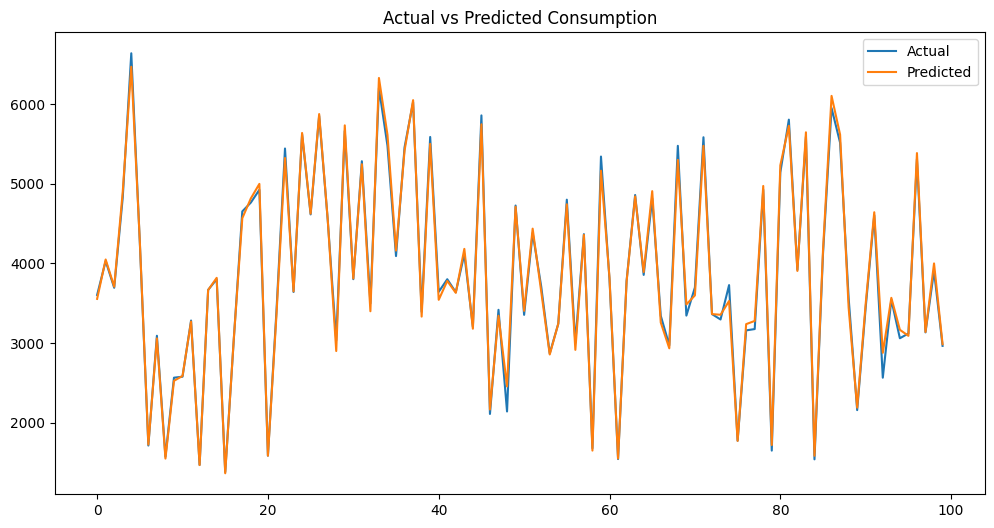

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    comparison['Actual'].values[:100],
    label='Actual'
)

plt.plot(
    comparison['Predicted'].values[:100],
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted Consumption")

plt.show()

# Feature Importance

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance

,Feature,Importance
0,Year,0.000000
1,Month,0.683642
2,Day,0.082733
3,DayOfWeek,0.028930
4,Hour,0.204695


# Feature Importance Plot

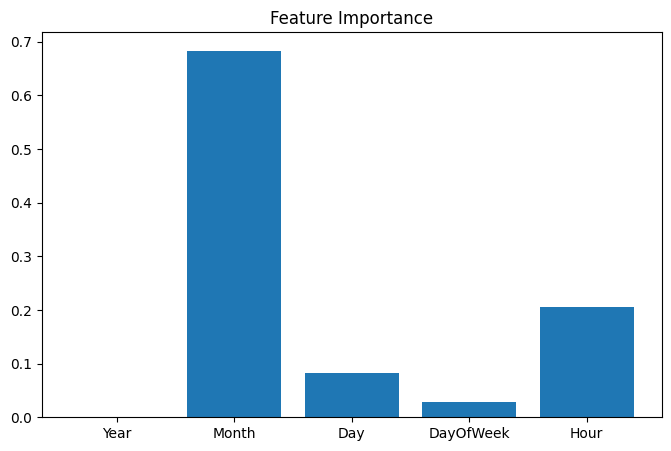

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.show()

# Predict New Consumption

In [18]:
new_data = pd.DataFrame({
    'Year': [2022],
    'Month': [7],
    'Day': [1],
    'DayOfWeek': [4],
    'Hour': [18]
})

prediction = model.predict(new_data)

print("Predicted Electricity Consumption:", prediction[0])

Predicted Electricity Consumption: 4728.886323476019


# Save Model

In [19]:
joblib.dump(
    model,
    "../Model/electricity_prediction.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Load Saved Model

In [20]:
loaded_model = joblib.load(
    "../Model/electricity_prediction.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


# Test Loaded Model

In [21]:
test_prediction = loaded_model.predict(new_data)

print("Prediction from loaded model:", test_prediction[0])

Prediction from loaded model: 4728.886323476019


# Final Summary

In [22]:
print("========== MODEL SUMMARY ==========")

print("Model Used: Random Forest Regressor")

print("\nR2 Score:", r2)

print("\nRMSE:", rmse)

print("\nModel Training Completed Successfully!")

========== MODEL SUMMARY ==========
Model Used: Random Forest Regressor

R2 Score: 0.9953060191589506

RMSE: 86.53603740338228

Model Training Completed Successfully!
